In [1]:
import pandas as pd
import numpy as np

import joblib

import matplotlib.pyplot as plt

from datetime import timedelta

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv(
    "../data/processed/final_featured_sales.csv"
)

df["Date"] = pd.to_datetime(
    df["Date"]
)

print(df.shape)

(6435, 42)


Load Model

In [3]:
best_model = joblib.load(
    "../models/best_model.pkl"
)

print(best_model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)


Prepare Dataset

In [4]:
df_model = pd.get_dummies(
    df,
    columns=["Festival_Name"],
    drop_first=True
)

df_model.drop(
    columns=["Date"],
    inplace=True
)

Create Training Features

In [5]:
TARGET = "Weekly_Sales"

X = df_model.drop(
    columns=[TARGET]
)

Get Latest Record

In [39]:
latest_row = X.iloc[-1:].copy()

latest_row

,Store,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,Quarter,...,Festival_Name_Easter,Festival_Name_Ganesh_Chaturthi,Festival_Name_Halloween,Festival_Name_Holi,Festival_Name_Independence_Day,Festival_Name_Janmashtami,Festival_Name_Labor_Day,Festival_Name_New_Year,Festival_Name_Raksha_Bandhan,Festival_Name_Valentines_Day
6434,45,0,58.85,3.882,192.308899,8.667,2012,10,43,4,...,False,False,True,False,False,False,False,False,False,False


In [24]:
feature_columns = X.columns.tolist()

Recursive Forecast

In [27]:
def recursive_forecast(
    model,
    df,
    forecast_periods=90
):

    forecast_results = []

    history = df.copy()

    for step in range(forecast_periods):

        latest = history.iloc[-1:].copy()

        prediction_input = latest.copy()
        
        # Remove columns not used during training
        prediction_input = prediction_input.drop(
            columns=[
                "Date",
                "Festival_Name",
                "Weekly_Sales"
            ],
            errors="ignore"
        )
        
        # Match training columns
        prediction_input = prediction_input.reindex(
            columns=feature_columns,
            fill_value=0
        )
        
        prediction = model.predict(
            prediction_input
        )[0]

        next_row = latest.copy()

        # --------------------------------
        # Target prediction
        # --------------------------------

        next_row["Weekly_Sales"] = prediction

        # --------------------------------
        # Future Date
        # --------------------------------

        next_row["Date"] = (
            pd.to_datetime(
                next_row["Date"]
            )
            +
            pd.Timedelta(days=7)
        )

        # --------------------------------
        # Update Time Features
        # --------------------------------

        next_date = pd.to_datetime(
            next_row["Date"].values[0]
        )

        next_row["Year"] = next_date.year
        next_row["Month"] = next_date.month
        next_row["Week"] = next_date.isocalendar().week
        next_row["Quarter"] = next_date.quarter
        next_row["Day"] = next_date.day
        next_row["DayOfWeek"] = next_date.dayofweek

        # --------------------------------
        # Update Lag Features
        # --------------------------------

        sales_history = history[
            "Weekly_Sales"
        ].values

        next_row["Lag_1"] = sales_history[-1]

        if len(sales_history) >= 4:
            next_row["Lag_4"] = sales_history[-4]

        if len(sales_history) >= 12:
            next_row["Lag_12"] = sales_history[-12]

        # --------------------------------
        # Rolling Mean
        # --------------------------------

        next_row["Rolling_Mean_4"] = np.mean(
            sales_history[-4:]
        )

        next_row["Rolling_Std_4"] = np.std(
            sales_history[-4:]
        )

        # --------------------------------
        # Moving Average
        # --------------------------------

        next_row["Moving_Average_8"] = np.mean(
            sales_history[-8:]
        )

        # --------------------------------
        # Sales Growth
        # --------------------------------

        next_row["Sales_Growth"] = (

            prediction
            -
            sales_history[-1]

        ) / sales_history[-1]

        # --------------------------------
        # Trend Score Simulation
        # --------------------------------

        next_row["Trend_Score"] = np.clip(

            latest["Trend_Score"].values[0]

            +

            np.random.normal(0, 3),

            0,

            100

        )

        # --------------------------------
        # Mention Count
        # --------------------------------

        next_row["Mention_Count"] = int(

            next_row["Trend_Score"]

            * 100

            +

            np.random.randint(
                1000,
                5000
            )

        )

        # --------------------------------
        # Engagement Rate
        # --------------------------------

        next_row["Engagement_Rate"] = np.clip(

            latest["Engagement_Rate"].values[0]

            +

            np.random.normal(
                0,
                0.5
            ),

            1,

            20

        )

        # --------------------------------
        # Sentiment
        # --------------------------------

        next_row["Sentiment_Score"] = np.clip(

            latest["Sentiment_Score"].values[0]

            +

            np.random.normal(
                0,
                0.05
            ),

            -1,

            1

        )

        # --------------------------------
        # Influencer Activity
        # --------------------------------

        next_row[
            "Influencer_Promotion_Flag"
        ] = np.random.choice(
            [0, 1],
            p=[0.7, 0.3]
        )

        # --------------------------------
        # Viral Campaign
        # --------------------------------

        next_row[
            "Viral_Campaign_Flag"
        ] = np.where(

            (
                next_row[
                    "Trend_Score"
                ].values[0]
                > 80
            )

            and

            (
                next_row[
                    "Influencer_Promotion_Flag"
                ].values[0]
                == 1
            ),

            1,

            0

        )

        # --------------------------------
        # Save Forecast
        # --------------------------------

        forecast_results.append(

            [
                next_date,
                prediction
            ]

        )

        history = pd.concat(
            [
                history,
                next_row
            ],
            ignore_index=True
        )

    return pd.DataFrame(

        forecast_results,

        columns=[
            "Date",
            "Predicted_Sales"
        ]

    )

Forecast DataFrame

In [28]:
forecast_df = recursive_forecast(
    best_model,
    df,
    forecast_periods=90
)

forecast_df.head()

,Date,Predicted_Sales
0,2012-11-02,760260.9375
1,2012-11-09,752672.7500
2,2012-11-16,752385.5000
3,2012-11-23,754594.8750
4,2012-11-30,756442.0625


Confidence Interval

In [29]:
forecast_df["Lower_Bound"] = (
    forecast_df["Predicted_Sales"] * 0.95
)

forecast_df["Upper_Bound"] = (
    forecast_df["Predicted_Sales"] * 1.05
)

Forecast Curve

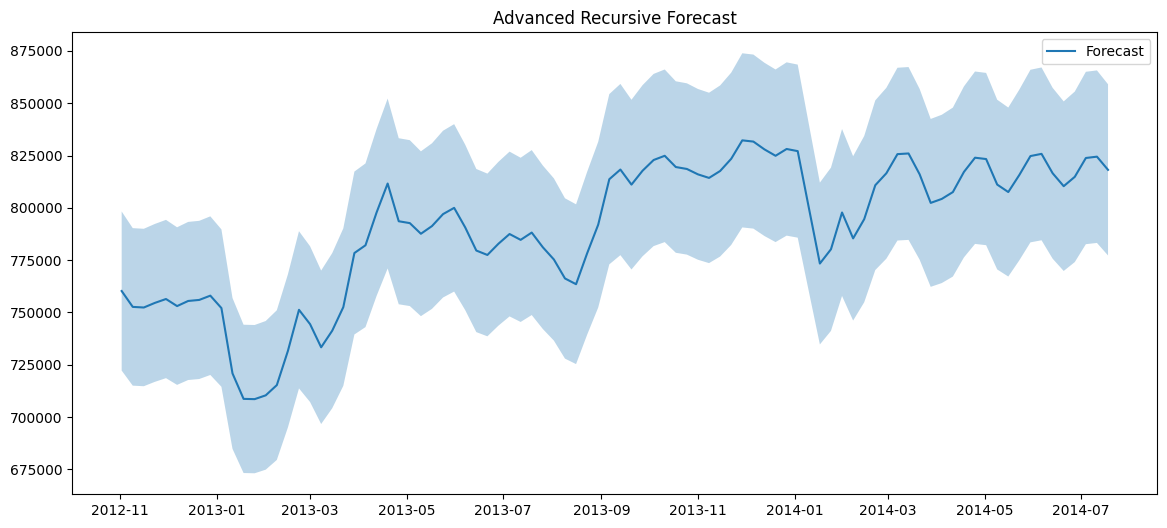

In [30]:
plt.figure(figsize=(14,6))

plt.plot(
    forecast_df["Date"],
    forecast_df["Predicted_Sales"],
    label="Forecast"
)

plt.fill_between(
    forecast_df["Date"],
    forecast_df["Lower_Bound"],
    forecast_df["Upper_Bound"],
    alpha=0.3
)

plt.legend()

plt.title(
    "Advanced Recursive Forecast"
)

plt.show()

View Forecast

In [31]:
forecast_df.head(20)

,Date,Predicted_Sales,Lower_Bound,Upper_Bound
0,2012-11-02,760260.9375,722247.8750,798273.9375
1,2012-11-09,752672.7500,715039.1250,790306.3750
2,2012-11-16,752385.5000,714766.1875,790004.7500
3,2012-11-23,754594.8750,716865.1250,792324.5625
4,2012-11-30,756442.0625,718619.9375,794264.1250
5,2012-12-07,753063.6250,715410.4375,790716.7500
6,2012-12-14,755506.3750,717731.0625,793281.6875
7,2012-12-21,756005.8125,718205.5000,793806.0625
8,2012-12-28,758044.6250,720142.3750,795946.8125
9,2013-01-04,752115.1875,714509.4375,789720.9375


Demand Peak Detection

In [33]:
peak_threshold = (

    forecast_df["Predicted_Sales"]

    .quantile(0.90)

)

peaks = forecast_df[

    forecast_df["Predicted_Sales"]

    >= peak_threshold

]

peaks.head()

,Date,Predicted_Sales,Lower_Bound,Upper_Bound
56,2013-11-29,832256.7500,790643.8750,873869.5625
57,2013-12-06,831672.3125,790088.6875,873255.8750
58,2013-12-13,827938.6250,786541.6875,869335.5000
59,2013-12-20,824883.7500,783639.5625,866127.8750
60,2013-12-27,828135.2500,786728.5000,869542.0000


Visualize Peaks

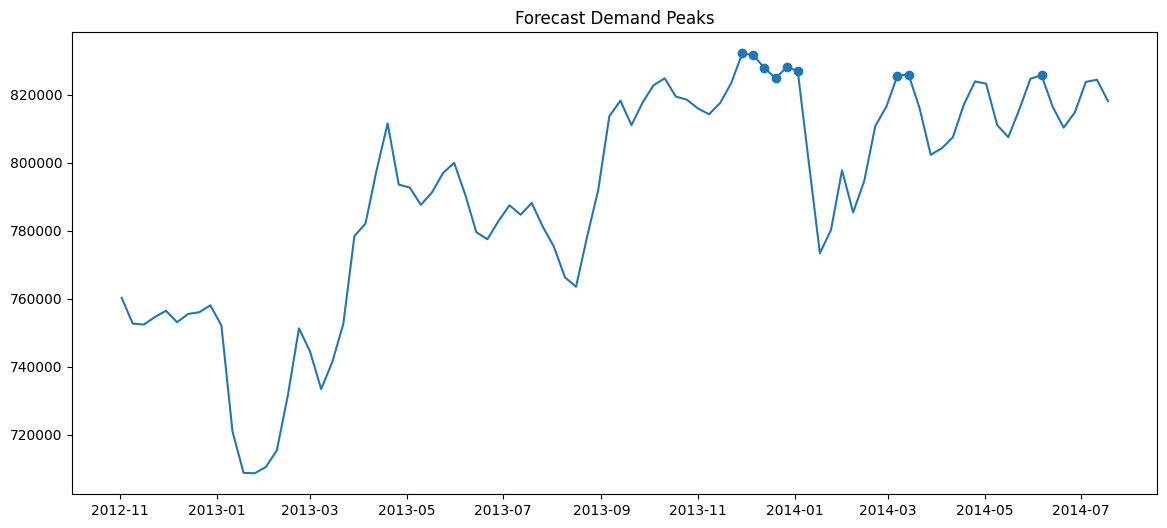

In [34]:
plt.figure(figsize=(14,6))

plt.plot(

    forecast_df["Date"],

    forecast_df["Predicted_Sales"]

)

plt.scatter(

    peaks["Date"],

    peaks["Predicted_Sales"]

)

plt.title(
    "Forecast Demand Peaks"
)

plt.show()

Top Demand Weeks

In [35]:
forecast_df.sort_values(

    "Predicted_Sales",

    ascending=False

).head(10)

,Date,Predicted_Sales,Lower_Bound,Upper_Bound
56,2013-11-29,832256.7500,790643.8750,873869.5625
57,2013-12-06,831672.3125,790088.6875,873255.8750
60,2013-12-27,828135.2500,786728.5000,869542.0000
58,2013-12-13,827938.6250,786541.6875,869335.5000
61,2014-01-03,827108.8125,785753.3750,868464.1875
71,2014-03-14,825991.3125,784691.7500,867290.8125
83,2014-06-06,825803.1875,784513.0000,867093.3125
70,2014-03-07,825673.1250,784389.4375,866956.7500
59,2013-12-20,824883.7500,783639.5625,866127.8750
49,2013-10-11,824881.6250,783637.5625,866125.6875


Save Forecast

In [38]:
forecast_df.to_csv(
    "../outputs/forecast_results.csv",
    index=False
)

print("Forecast saved successfully!")

Forecast saved successfully!
